In [2]:
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
from formulas import density_profile
from formulas import Poisson_equation
from formulas import star_density
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from ode_solvers import rk4_method_second_order_2D

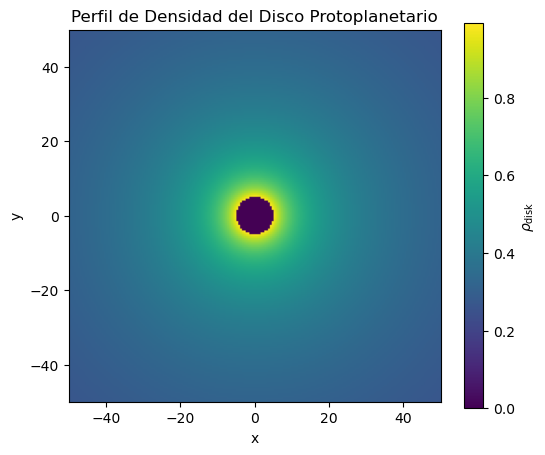

In [3]:

#creamos la malla

au = 1.0 # 1 ua
Nx, Ny = 200, 200  #tamaño de la malla
L =50.0*au  #dimensiones físicas del espacio en metros

x = np.linspace(-L, L, Nx)
y = np.linspace(-L, L, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y) 
R = np.sqrt(X**2 + Y**2)

#elegimos parametros generales para el disco 
rho_0 = 0.5 #densidad de referencia
r_0 = 20.0*au #radio de referencia
p = 0.5 #indice de densidad
r_min = 5.0*au #radio del hueco interno


rho_disk = density_profile(R, rho_0, r_0, p, r_min)

#------Grafico -----
plt.figure(figsize=(6,5))
plt.imshow(rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho_{\mathrm{disk}}$')   
plt.xlabel('x')
plt.ylabel('y')
plt.title('Perfil de Densidad del Disco Protoplanetario')
plt.show()



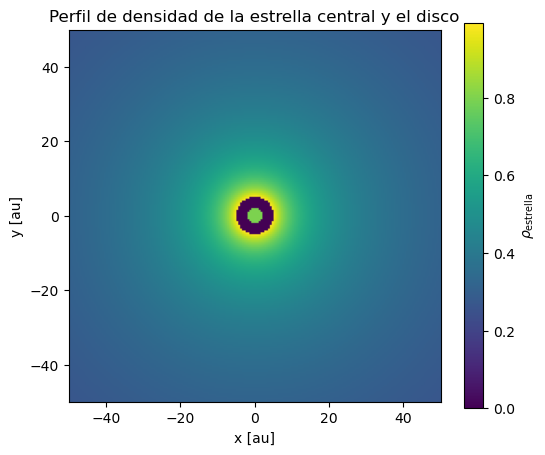

In [4]:
#graficar la densidad de la estrella

#elegimos parametros generales para la estrella
Mass_star = 10.0
Radius_star = 2.0*au   
star_density_profile = star_density(X, Y, Mass_star, Radius_star)


#------Grafico -----
plt.figure(figsize=(6,5))
plt.imshow(star_density_profile + rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho_{\mathrm{estrella}}$')   
plt.xlabel('x [au]')
plt.ylabel('y [au]')
plt.title('Perfil de densidad de la estrella central y el disco')
plt.show()

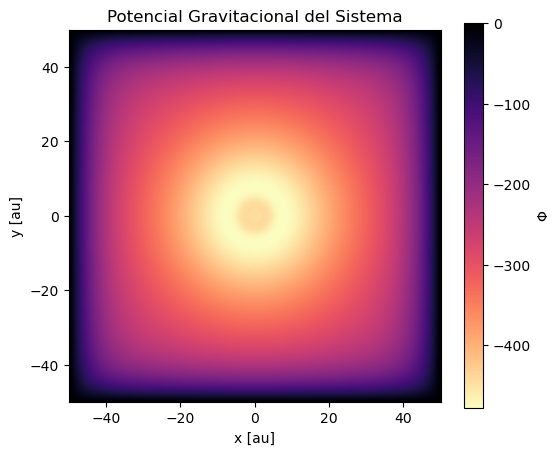

In [5]:
#graficamos el potencial gravitacional del sistema
Gradient_potential = Poisson_equation(dx= dx, star_density=star_density_profile, disk_density=rho_disk, tol= 1e-4, max_iter= 1000)


#------Grafico -----

plt.figure(figsize=(6,5))
plt.imshow(Gradient_potential, extent=[-L, L, -L, L], origin='lower', cmap='magma_r')
plt.colorbar(label=r'$\Phi$')   
plt.xlabel('x [au]')
plt.ylabel('y [au]')
plt.title('Potencial Gravitacional del Sistema')
plt.show()

El gradiente del potencial gravitatorio en coordenadas cartesianas se escribe como:

$$ \vec{g} = - \vec{\nabla} \Phi = - \left(  \frac{\partial \Phi}{\partial x} , \frac{\partial \Phi}{\partial y} \right) $$

Puede calcular las componentes del campo gravitatorio $\vec{g} = (g_x, g_y)$ como:

$$
\begin{align*}
g_x & = - \frac{\partial \Phi}{\partial x} \approx - \frac{\Phi(x + \Delta x, y) - \Phi(x - \Delta x, y)}{2 \Delta x} = - \frac{\Phi_{i+1, j} - \Phi_{i-1, j}}{2 \Delta x}  \\
g_y & = - \frac{\partial \Phi}{\partial y} \approx - \frac{\Phi(x, y + \Delta y) - \Phi(x, y - \Delta y)}{2 \Delta y} = - \frac{\Phi_{i, j+1} - \Phi_{i, j-1}}{2 \Delta y} 
\end{align*}
$$

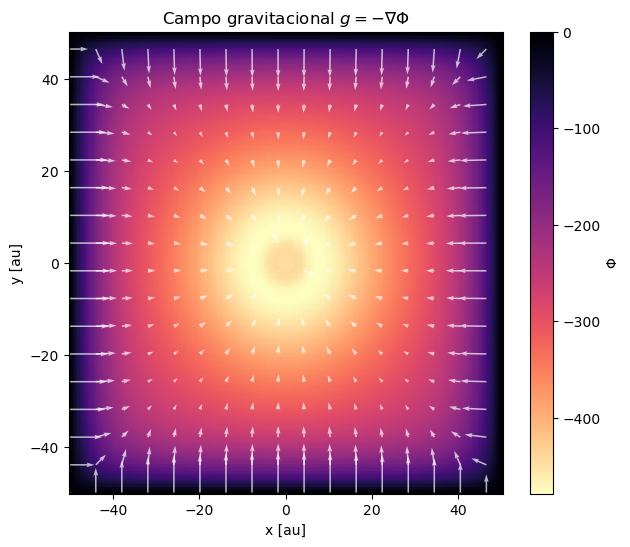

In [6]:

# phi tiene shape (Ny, Nx): eje 0 → y (dy), eje 1 → x (dx)
dphi_dy, dphi_dx = np.gradient(Gradient_potential, dy, dx) #crea el gradiente del potencial, con el orden correcto de los pasos espaciales
gx_raw = -dphi_dx   # componente x del campo: g = -∇Φ
gy_raw = -dphi_dy   # componente y del campo

# Interpoladores continuos — evitan la conversión a índice entero
# RegularGridInterpolator espera puntos en orden (eje0, eje1) = (y, x)
gx_interp = RegularGridInterpolator((y, x), gx_raw, method='linear',
                                     bounds_error=False, fill_value=0.0)
gy_interp = RegularGridInterpolator((y, x), gy_raw, method='linear',
                                     bounds_error=False, fill_value=0.0)




#------Grafico -----

# Visualización: mapa de potencial + flechas del campo
fig, ax = plt.subplots(figsize=(7, 6))

pcm = ax.pcolormesh(X, Y, Gradient_potential, cmap='magma_r', shading='auto')
plt.colorbar(pcm, ax=ax, label=r'$\Phi$')
step = 12
ax.quiver(X[::step, ::step], Y[::step, ::step],
          gx_raw[::step, ::step], gy_raw[::step, ::step],
          color='white', alpha=0.7, scale=None)
ax.set_xlabel('x [au]'); ax.set_ylabel('y [au]')
ax.set_title('Campo gravitacional $g = -\\nabla\\Phi$')
plt.show()

In [7]:
def second_law(t,r,v):
    """
    Ecuacion de segunda ley de newton con arrastre para discos protoplanetarios

    Ejemplo de condiciones iniciales
    t0= 0.0  # Tiempo inicial
    tf = 10.0  # Tiempo final
    n_steps = 1000  # Número de pasos de integración
    t=np.linspace(t0, tf, n_steps)
    init = np.array([10.0, 0.0, 20.0, 0.0])  # Condición inicial (posición y velocidad)
    v0_gas = 0.0  # Velocidad inicial del gas
    r0_gas = 5.0  # Radio inicial del gas
    alpha = 0.1  # Coeficiente de IDK BUSCAAAAAAAAAAAAR
    gamma = 0.1  # Coeficiente de fricción
    g = np.array([gx, gy])  # Campo gravitacional (debe ser una función o matriz que represente el campo)

    Args:
        t (array): Tiempo de integración
        init (array): Condición inicial (posición (x e y) y velocidad(x e y))
        v0_gas (constant): velocidad inicial del gas
        r0_gas (constant): radio de referencia del gas
        alpha (constant): idk
        gamma (constant): coeficiente de fricción
        g (array): campo gravitacional (debe ser una función o matriz que represente el campo)
    Returns:
        array: Derivada de la condición inicial (velocidad y aceleración)
        vx, vy: velocidad en x e y
        ax, ay: aceleración en x e y
    """
    v0_gas = 1.0  # Velocidad inicial del gas
    r0_gas = 10.0 *au  # Radio inicial del gas
    alpha = 0.5  # índice del perfil (0.5 ≈ kepleriano)
    gamma = 0.05  # Coeficiente de fricción
    #g = np.array([gx, gy]) 
    
    #descomponer la condición inicial de la particula
    
    x = r[0]
    y = r[1]
    
    
    vx = v[0]
    vy = v[1]
    #calcular el modulo del radio
    r_modulo = np.sqrt(x**2 + y**2)
    
    
    #calcular el potencial gravitacional en la posicion de la particula
    phi = np.array([-y/r_modulo, x/r_modulo])
    #calcular la velocidad del gas
    v_gas = v0_gas*((r0_gas/r_modulo)**alpha)*phi
    
    #calcular la malla gravitacional del sistema sobre la particula
    part     = np.array([[y, x]])
    ax_grav = gx_interp(part)[0]
    ay_grav = gy_interp(part)[0]
    
    
    # 3. Ecuación de movimiento final
    ax = ax_grav - gamma * (vx - v_gas[0])
    ay = ay_grav - gamma * (vy - v_gas[1])
    
    return np.array([ax, ay])

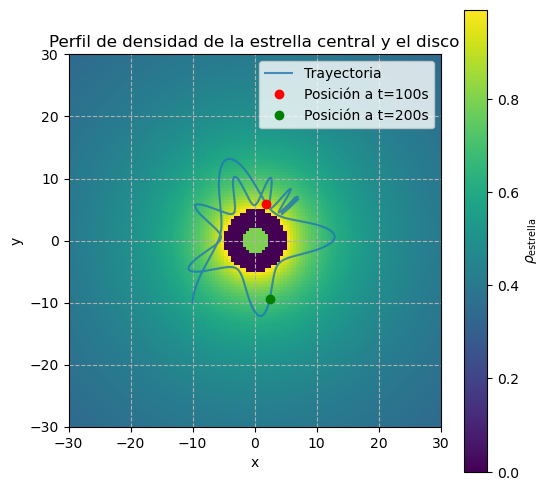

In [9]:


# Condiciones iniciales para la trayectoria
t0 = 0.0
tf = 40.0  
h = 0.05  

r0 = (-10.0, -10.0) 
v0 = (0.0, 5.0)  
#Aplicamos el método de Runge-Kutta para resolver la trayectoria de una partícula bajo el campo gravitacional
t, r, v = rk4_method_second_order_2D(second_law, t0=t0, tf=tf, r0=r0, v0=v0, h=h)

#------Grafico -----
plt.figure(figsize=(6,6))  
plt.imshow(star_density_profile + rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho_{\mathrm{estrella}}$')   
plt.plot(r[:, 0], r[:, 1], label='Trayectoria',alpha=0.8)
plt.plot(r[100, 0], r[100, 1], 'ro', label='Posición a t=100s')  # Ejemplo de punto específico
plt.plot(r[200, 0], r[200, 1], 'go', label='Posición a t=200s')  # Otro punto específico
plt.xlabel('x')
plt.ylabel('y')
plt.title('Perfil de densidad de la estrella central y el disco')
plt.ylim(-30, 30)
plt.xlim(-30, 30)
plt.grid(True, ls='--')
plt.legend()
plt.show()

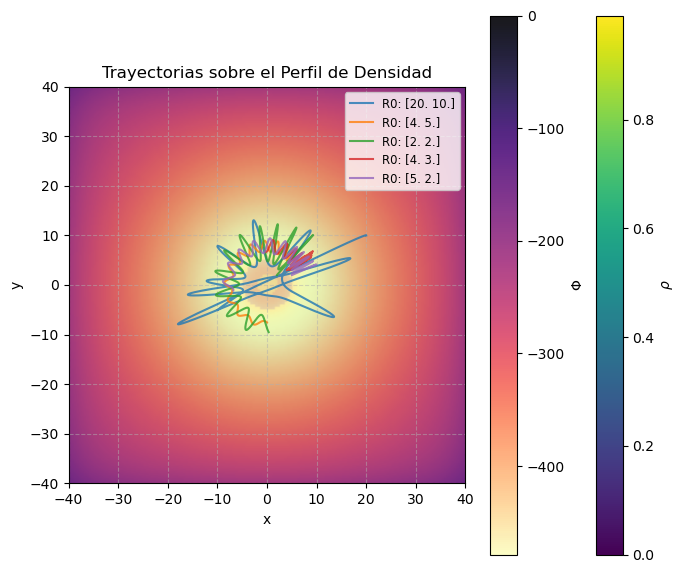

In [11]:

# Probamos con distintas condiciones iniciales para ver la variedad de trayectorias posibles

r_iniciales = np.array([[20.0, 10.0], [4.0, 5.0], [2.0, 2.0], [4.0, 3.0], [5.0, 2.0]])
v_iniciales = np.array([[0.3, 0.5], [0.2, 0.4], [0.1, 0.2], [0.05, 0.1], [0.01, 0.02]])


#------Grafico -----

plt.figure(figsize=(8, 7))
plt.imshow(star_density_profile + rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho$')


for i in range(len(r_iniciales)):
    
    t_sim, r_sim, v_sim = rk4_method_second_order_2D(
        second_law, t0=t0, tf=tf, r0=r_iniciales[i], v0=v_iniciales[i], h=h
    )

    
    plt.plot(r_sim[:, 0], r_sim[:, 1], label=f'R0: {r_iniciales[i]}', alpha=0.8)


plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias sobre el Perfil de Densidad')
plt.imshow(Gradient_potential, extent=[-L, L, -L, L], origin='lower', cmap='magma_r',alpha=0.9)
plt.colorbar(label=r'$\Phi$')   
plt.ylim(-40, 40) # Ajustado para ver mejor el detalle cerca del disco
plt.xlim(-40, 40)
plt.grid(True, ls='--', alpha=0.5)
plt.legend(loc='upper right', fontsize='small')
plt.show()

